In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import zscore 
# from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
# from statsmodels.tsa.seasonal import seasonal_decompose
from SimpleIsolationForest import IsolationForest

import warnings
warnings.filterwarnings('ignore')


In [2]:
#input parameters
stock_name = "NABIL";
train_start_date = "2020-01-01"
train_end_date = "2025-01-01"

test_start_date = "2025-01-01"
test_end_date = "2026-04-08"

features = ['price', 'quantity', 'return', 'SMA_5', 'SMA_20', 'EMA_10']
# features = ['price', 'quantity', 'return']


n_estimators=200
contamination=0.05

#n_estimators = 200 means 200 independent trees are built and then sees how quickly a given point gets isolated across these trees.
#contamination 0,2 assumes that 20% of the data is anomalous


# Random seed → generate random splits
#         ↓
# Build 200 isolation trees
#         ↓
# Compute anomaly scores
#         ↓
# Use contamination (2%) to label anomalies

#isolation forest converts the average path length to scores
# short path → high anomaly score
# long path → low anomaly score



In [ ]:
#Data preprocessing

data_source = stock_name+".csv";
df = pd.read_csv("data/"+data_source);

# print(df.columns)

df['Date'] = pd.to_datetime(df['transaction_time'])
df = df.drop(columns=['transaction_time'])
df = df.sort_values('Date');
df = df.set_index('Date');


# # Filter dataframe
df = df.drop_duplicates()

# Compute return
df['return'] = df['price'].pct_change()
df['price'] = df['price'].replace(0, np.nan)


# Simple Moving Average (SMA)
df['SMA_5'] = df['price'].rolling(window=5).mean()  # 5-day moving average
df['SMA_20'] = df['price'].rolling(window=20).mean() # 20-day moving average

# Exponential Moving Average (EMA)
df['EMA_10'] = df['price'].ewm(span=10, adjust=False).mean()


# df= df.dropna()
# print((df['return'].isna()).sum())
# df.head()


#Take only the required date range
df = df.loc[train_start_date:test_end_date].copy()

X = df[features] #Take only the selected columns from the data frame



# print(df['status'].unique())
#In status 1 means the stock increased -1 decreased and 0 means same from the previous closing price

# Anomalies are easier to isolate than normal points.
# Because anomalies are rare and far from the cluster, a random split can isolate them quickly.
# Normal points are surrounded by many neighbors, so they require more splits



# Time-based train/test split + scaling + new IsolationForest model

df[features] = df[features].apply(pd.to_numeric, errors='coerce') #converts every value in features columns to numeric value
df.replace([np.inf, -np.inf], np.nan, inplace=True) #replace inf and -inf with NaN inplace means in the original dataframe


df = df.dropna(subset=features) #drops rows where any of the features are NaN


KeyError: 'price'

In [ ]:
#Training and Testing

# split_idx = int(len(df) * 0.8) #splits the dataframe into 80% train and 20% test

# df_train = df.iloc[:split_idx].copy() #creates a copy of the train dataframe from the first 80% of the dataframe
# df_test = df.iloc[split_idx:].copy() #creates a copy of the test dataframe from the last 20% of the dataframe


df_train = df.loc[train_start_date:train_end_date].copy()
df_test = df.loc[test_start_date:test_end_date].copy()




scaler = StandardScaler() #standardizes the data
X_train = scaler.fit_transform(df_train[features]) #standardizes the train data
X_test = scaler.transform(df_test[features]) #standardizes the test data

#to standardize means to convert the data to have a mean of 0 and a standard deviation of 1 such that the data is normalized and the model can learn better
#this is important because the model is sensitive to the scale of the data as return maybe in the range of -0.2 to 0.2 but the other features are in the range of 1000 to 1000000 like quantity

max_depth = int(np.ceil(np.log2(len(X_train))))
#ceil(log2(max_samples))

model_if = IsolationForest(
    n_trees=n_estimators,
    contamination=contamination,
    max_depth = max_depth
)

model_if.fit(X_train)
df_train['Anomaly_IF'] = model_if.anomaly_score(X_train) - model_if.threshold < 0;


#calc anomaly scores of test data
scores = model_if.anomaly_score(X_test)

# Store scores
df_test['anomaly_score'] = scores

# Use the threshold to get anomalies directly (without recomputing)
df_test['Anomaly_IF'] = scores - model_if.threshold < 0 

# df_test[df_test['Anomaly_IF']==True].sort_index(ascending=False).head()


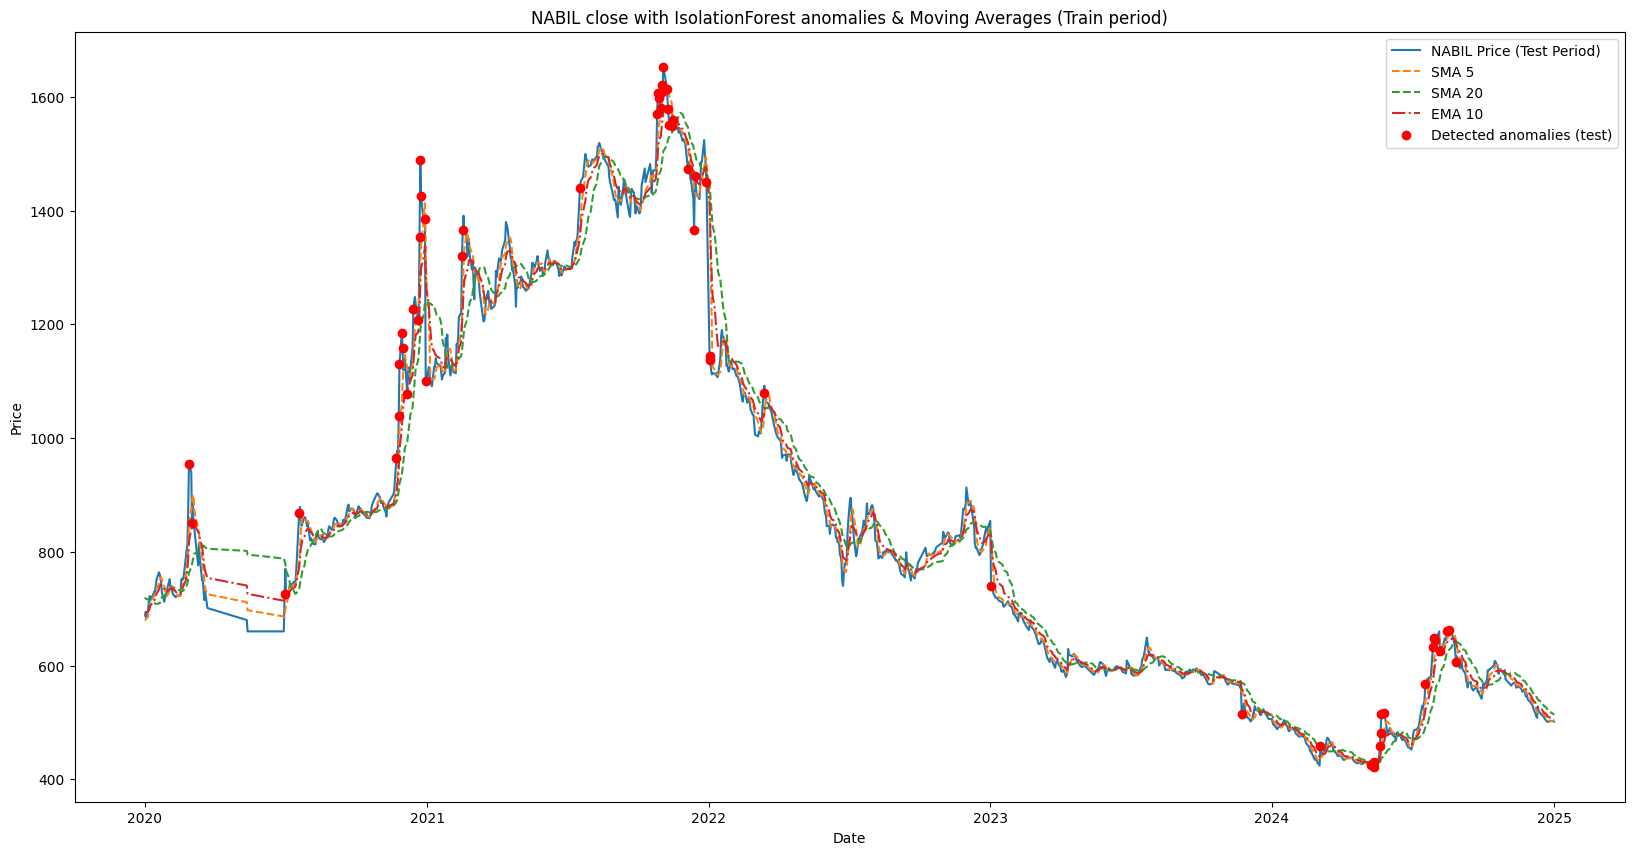

In [ ]:
# Plot price with detected anomalies on the train period

plt.figure(figsize=(20, 10))
# Plot test price prices
plt.plot(df_train.index, df_train['price'], label=f"{stock_name} Price (Test Period)")

# Plot moving averages (only for test period)
plt.plot(df_train.index, df_train['SMA_5'], label='SMA 5', linestyle='--', zorder=3)
plt.plot(df_train.index, df_train['SMA_20'], label='SMA 20', linestyle='--', zorder=3)
plt.plot(df_train.index, df_train['EMA_10'], label='EMA 10', linestyle='-.', zorder=3)

# Highlight anomalies
anomaly_idx = df_train.index[df_train['Anomaly_IF']]
plt.scatter(
    anomaly_idx,
    df_train.loc[anomaly_idx, 'price'],
    color='red',
    label='Detected anomalies (test)',
    zorder=5
)
#draws points with x-axis anomalies, 
# y-axis is price of the anomalies. df_test is the test data, loc lets you select the rows by labels and specific columns. i.e the label is the list or index of dates where indexes appear
#so we select all the rows in anomaly idx and from each row get the value of 'price Column'

plt.title(f"{stock_name} price with IsolationForest anomalies & Moving Averages (Train period)")
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# df_to_save = df[['price','quantity','return','SMA_5', 'SMA_20', 'EMA_10']].copy()

# df_to_save.to_csv("output_plotted_data.csv")

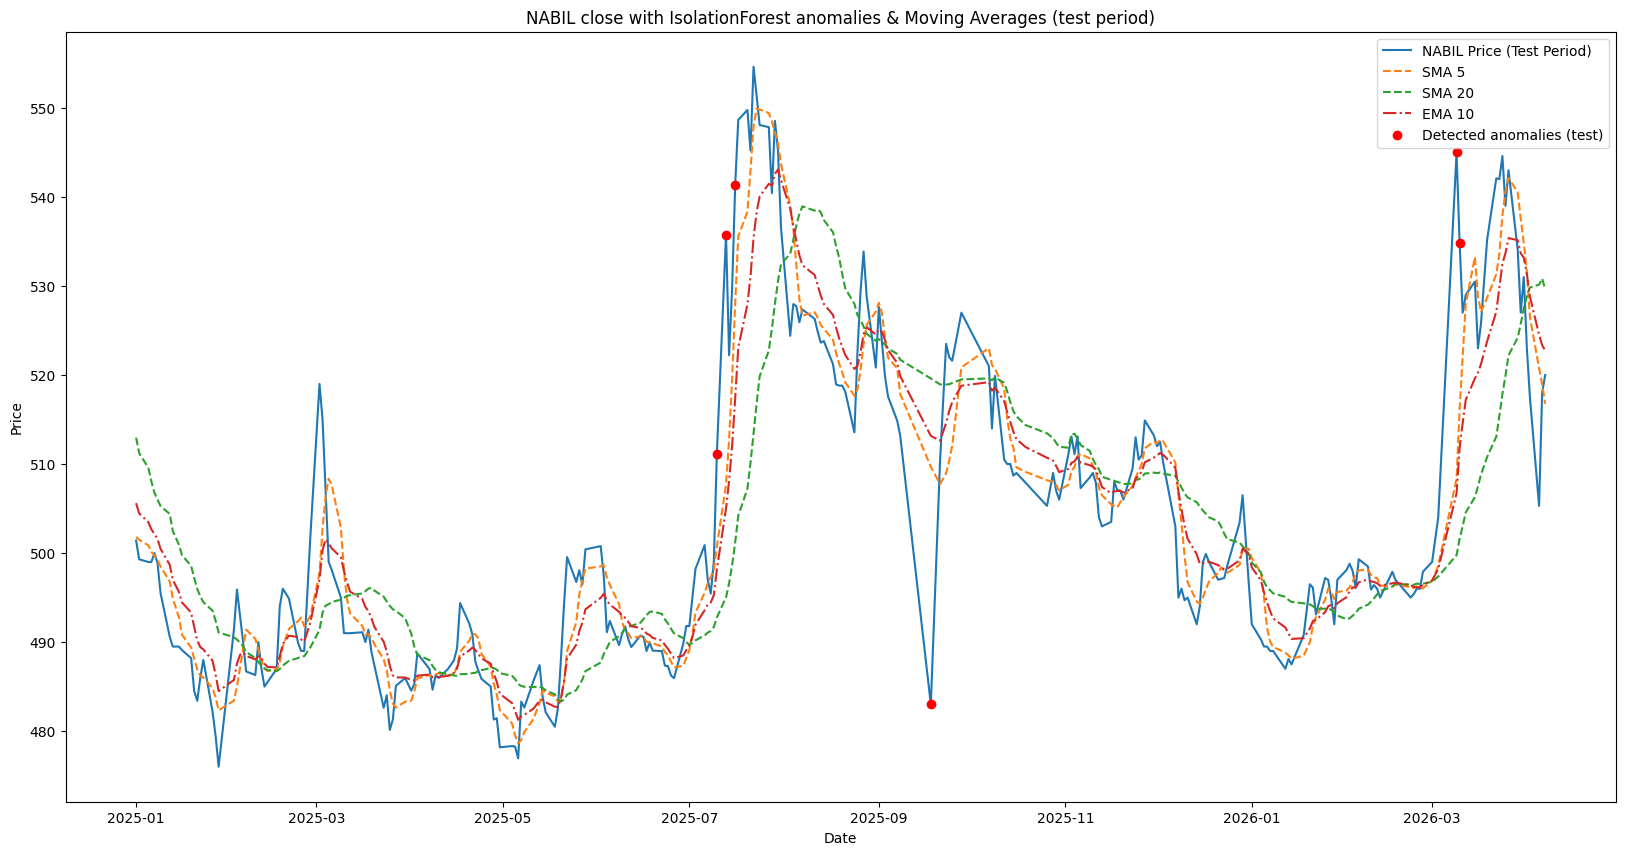

In [ ]:
# Plot price with detected anomalies on the test period

plt.figure(figsize=(20, 10))
# Plot test price prices
plt.plot(df_test.index, df_test['price'], label=f"{stock_name} Price (Test Period)")

# Plot moving averages (only for test period)
plt.plot(df_test.index, df_test['SMA_5'], label='SMA 5', linestyle='--', zorder=3)
plt.plot(df_test.index, df_test['SMA_20'], label='SMA 20', linestyle='--', zorder=3)
plt.plot(df_test.index, df_test['EMA_10'], label='EMA 10', linestyle='-.', zorder=3)

# Highlight anomalies
anomaly_idx = df_test.index[df_test['Anomaly_IF']]
plt.scatter(
    anomaly_idx,
    df_test.loc[anomaly_idx, 'price'],
    color='red',
    label='Detected anomalies (test)',
    zorder=5
)
#draws points with x-axis anomalies, 
# y-axis is price of the anomalies. df_test is the test data, loc lets you select the rows by labels and specific columns. i.e the label is the list or index of dates where indexes appear
#so we select all the rows in anomaly idx and from each row get the value of 'price Column'

plt.title(f"{stock_name} price with IsolationForest anomalies & Moving Averages (test period)")
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# df_to_save = df[['price','quantity','return','SMA_5', 'SMA_20', 'EMA_10']].copy()

# df_to_save.to_csv("output_plotted_data.csv")

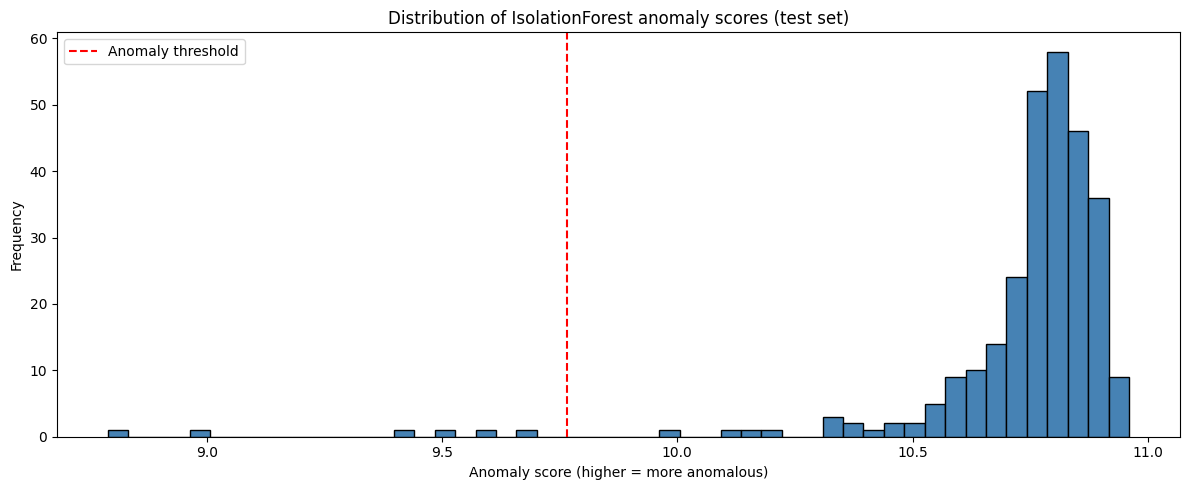

Anomaly counts in test set:
Anomaly_IF
False    277
True       6
Name: count, dtype: int64


In [ ]:
# Diagnostics: distribution of anomaly scores and counts
plt.figure(figsize=(12, 5))
plt.hist(df_test['anomaly_score'], bins=50, color='steelblue', edgecolor='black')
#draws 50 histogram blocks with blue fills and black borders based on the anomaly score of test data
plt.axvline(model_if.threshold, color='red', linestyle='--', label='Anomaly threshold')
#draws a vertical red line at threshold value. right side of threshold is anomalies
plt.title('Distribution of IsolationForest anomaly scores (test set)')
plt.xlabel('Anomaly score (higher = more anomalous)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout() #this is to make sure the plot is not too crowded
plt.show()

print('Anomaly counts in test set:')
print(df_test['Anomaly_IF'].value_counts())

#shows the count of anomalies and normal points
#also shows that roughly 2% of data were anomalies 

In [ ]:
# Inspect and optionally save the top-N anomalies from the test period
top_n = 20

TopAnoms = df_test.sort_values('anomaly_score', ascending=True).head(top_n)
print(f"The anomaly threshold is {model_if.threshold}")
print(f"Top {top_n} most anomalous dates in test set:")
TopAnoms[['price', 'quantity', 'return', 'anomaly_score', 'Anomaly_IF']]



#MAJOR EVENTS
#2025-09-* is the GENZ Revolution

#20**-07-* is the Federal Budget Season

#2026-03-09 NEPSE Hits 6% circuit breaker after R.S.P Win
#The next day 2026-03-10 ppl boooked profits and it fell

#2026-03-29 After formation of new govt Oli and Lekhak were arrested leading to NEPSE falling
#2026-04-05 Jagadamba Group CEO was arrested leading to NEPSE freefall 
#2026-03-22 Official win of R.S.P




The anomaly threshold is 9.765
Top 20 most anomalous dates in test set:


,close,traded_quantity,Return,anomaly_score,Anomaly_IF
Date,,,,,
2026-03-09,545.00,4906.0,0.081349,8.790,True
2025-07-13,535.77,270279.0,0.048125,8.975,True
2025-07-10,511.17,264663.0,0.024368,9.430,True
2026-03-10,534.80,271844.0,-0.018716,9.515,True
2025-09-18,483.00,16660.0,-0.058755,9.575,True
2025-07-16,541.37,260180.0,0.021838,9.670,True
2025-09-21,510.18,122490.0,0.056273,9.990,False
2025-07-17,548.66,192877.0,0.013466,10.135,False
2025-07-20,549.77,233008.0,0.002023,10.160,False


In [ ]:
import sys
print(sys.version)

3.14.3 (main, Feb 13 2026, 15:31:44) [GCC 15.2.1 20260209]
